In [1]:
# %%
import os
import random
from tqdm.autonotebook import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from enum import Enum
import cv2
from tensorflow.keras import backend as K  # Keras backend (included in TensorFlow)
import gc
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import csv
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import Dense, Dropout

# Import numpy.dstack
from numpy import dstack

# Alternative for TensorFlow Addons
from sklearn.metrics import cohen_kappa_score, accuracy_score

C:\Users\vit\AppData\Local\Temp\ipykernel_23448\3399024290.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
# %%
seed = 3352024
os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
tf.random.set_seed(seed)
np.random.seed(seed)

In [3]:
# %%
def load_path(path):
    """
    Load MURA dataset with corresponding labels and file paths
    """
    dataset = []
    for body in os.listdir(path):
        path_p = os.path.join(path, body)
        # print(os.listdir(path_p))
        for id_p in os.listdir(path_p):
            # print(id_p)
            path_id = os.path.join(path_p, id_p)
            # print(os.listdir(path_id))
            for lab in os.listdir(path_id):
                label = 1 if "positive" in lab else 0
                path_l = os.path.join(path_id, lab)
                for img in os.listdir(path_l):
                    img_path = os.path.join(path_l, img)
                    dataset.append(
                        {
                            "body_part": body,
                            "patient_id": id_p,
                            "label": label,
                            "img_path": img_path,
                        }
                    )
    return dataset


In [4]:
# Load the train dataset
train_path = os.path.join(os.getcwd(), "C://Users//vit//Rishabh ML project//MURA-v1.1//train")
dataset_train = load_path(train_path)
df_train = pd.DataFrame(dataset_train)


In [5]:
# %%
# Load the validation dataset
valid_path = os.path.join(os.path.join(os.getcwd(), "C://Users//vit//Rishabh ML project//MURA-v1.1//valid"))
dataset_valid = load_path(valid_path)
df_valid = pd.DataFrame(dataset_valid)


In [6]:
# %%
# CSV file paths for train and validation sets
#path = os.path.join('C://Users//vit//Documents//Rishabh//MURA-v1.1')
train_image_paths_csv = "C://Users//vit//Rishabh ML project//MURA-v1.1//train_image_paths.csv"
valid_image_paths_csv = "C://Users//vit//Rishabh ML project//MURA-v1.1//valid_image_paths.csv"


In [7]:
# %%
# Function to load CSV file and return DataFrame
def load_csv(file_path):
    try:
        with open(file_path, mode="r", newline="", encoding="utf-8") as file:
            reader = csv.reader(file)
            header = next(reader)  # Assuming there's a header
            data = [row for row in reader]
        return pd.DataFrame(data, columns=["image_path"])
    except Exception as e:
        print(f"Error reading the CSV file: {e}")
        return pd.DataFrame()


In [8]:
# %%
# Load CSV data into DataFrames
train_images_paths = load_csv(os.path.join(os.getcwd(), train_image_paths_csv))
valid_images_paths = load_csv(os.path.join(os.getcwd(), valid_image_paths_csv))


In [9]:
# %%
# Check if all image paths are valid
def check_image_paths(df):
    for image_path in df["image_path"]:
        if not os.path.exists(image_path):
            print(f"File not found: {image_path}")


check_image_paths(train_images_paths)
check_image_paths(valid_images_paths)


In [10]:
# %%
# Image display function
def load_and_show_image(image_path):
    image = cv2.imread(image_path)
    if image is not None:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.imshow(image)
        plt.axis("off")
        plt.show()
    else:
        print(f"Unable to load image at {image_path}")


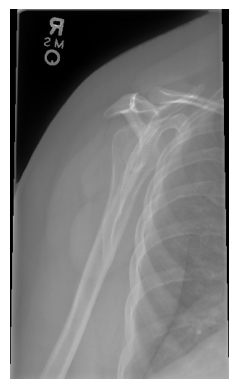

In [11]:
# %%
# Load and show the first image
load_and_show_image(train_images_paths.iloc[0]["image_path"])


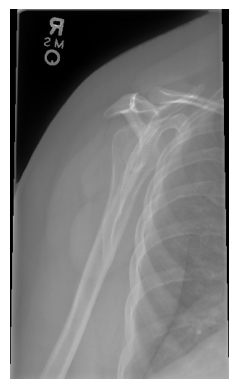

In [12]:
# %%
# Load and show the first image
load_and_show_image(train_images_paths.iloc[0]["image_path"])

# %%
# Add labels and other columns to DataFrame
train_images_paths["label"] = train_images_paths["image_path"].apply(
    lambda x: "positive" if "positive" in x else "negative"
)
train_images_paths["category"] = train_images_paths["image_path"].apply(
    lambda x: x.split("/")[2]
)
train_images_paths["patientId"] = train_images_paths["image_path"].apply(
    lambda x: x.split("/")[3].replace("patient", "")
)
train_images_paths["label_index"] = train_images_paths["label"].map(
    {"positive": 1, "negative": 0}
)


In [13]:
# %%
valid_images_paths["label"] = valid_images_paths["image_path"].apply(
    lambda x: "positive" if "positive" in x else "negative"
)
valid_images_paths["category"] = valid_images_paths["image_path"].apply(
    lambda x: x.split("/")[2]
)
valid_images_paths["dir"] = valid_images_paths["image_path"].apply(
    lambda x: x.split("/")[1]
)
valid_images_paths["patientId"] = valid_images_paths["image_path"].apply(
    lambda x: x.split("/")[3].replace("patient", "")
)
valid_images_paths["label_index"] = valid_images_paths["label"].map(
    {"positive": 1, "negative": 0}
)


In [14]:
# %%
# Image Preprocessing for model
def random_rotation_flip(image, size=256):
    if random.randint(0, 1):
        image = cv2.flip(image, 1)  # Horizontal flip

    if random.randint(0, 1):
        angle = random.randint(-30, 30)
        M = cv2.getRotationMatrix2D((size / 2, size / 2), angle, 1)
        image = cv2.warpAffine(image, M, (size, size))

    return image


In [15]:
# %%
# Function to load and preprocess images
def image_loader(paths, size=224):
    Images = []
    for path in tqdm(paths):
        try:
            if not os.path.exists(path):
                print(f"Warning: File does not exist at {path}. Skipping.")
                continue

            image = cv2.imread(path)
            # image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if image is None:
                print(f"Warning: Unable to load image at {path}. Skipping.")
                continue

            image = cv2.resize(image, (size, size))
            image = random_rotation_flip(image, size)
            Images.append(np.asarray(image).astype("float32"))

        except Exception as e:
            print(f"Error processing image at {path}: {str(e)}")

    if len(Images) == 0:
        print("Error: No images were loaded. Please check your paths and files.")
        return None

    Images = np.array(Images)
    mean = np.mean(Images)
    std = np.std(Images)
    Images = (Images - mean) / std  # Standardize images

    return Images

In [16]:
# %%
# Load training images (limit to 25,000 for now)
X_train = image_loader(train_images_paths["image_path"][:15000], size=256)


  0%|          | 0/15000 [00:00<?, ?it/s]

In [17]:
# %%
X_train.shape


(15000, 256, 256, 3)

In [18]:
# %%
Y_train = train_images_paths["label_index"][:15000]
Y_test = valid_images_paths["label_index"][:5000]


In [19]:
# %%
X_test = image_loader(valid_images_paths["image_path"][:5000], size=256)


  0%|          | 0/3196 [00:00<?, ?it/s]

In [20]:
# %%
X_test.shape


(3196, 256, 256, 3)

In [21]:
# %%
# Setup ImageDataGenerator for augmentation
datagen = ImageDataGenerator(rescale=1.0 / 255)
# train_generator = datagen.flow_from_dataframe(
#     dataframe=train_images_paths,
#     x_col="image_path",
#     target_size=(256, 256),
#     batch_size=32,
#     class_mode=None,
#     shuffle=True,
#     dtype=tf.float32,
# )

In [22]:
train_generator = datagen.flow(X_train, Y_train, batch_size=16)
#valid_generator = datagen.flow(X_test, Y_test, batch_size=32)


In [23]:
valid_generator = datagen.flow(X_test, Y_test, batch_size=16)

In [24]:
# %%
train_images_paths["label_index"] = train_images_paths.label
valid_images_paths["label_index"] = valid_images_paths.label


In [25]:
# %%
train_images_paths


,image_path,label,category,patientId,label_index
0,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,positive,XR_SHOULDER,00001,positive
1,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,positive,XR_SHOULDER,00001,positive
2,MURA-v1.1/train/XR_SHOULDER/patient00002/study...,positive,XR_SHOULDER,00002,positive
3,MURA-v1.1/train/XR_SHOULDER/patient00002/study...,positive,XR_SHOULDER,00002,positive
4,MURA-v1.1/train/XR_SHOULDER/patient00002/study...,positive,XR_SHOULDER,00002,positive
...,...,...,...,...,...
36802,MURA-v1.1/train/XR_HAND/patient11183/study1_ne...,negative,XR_HAND,11183,negative
36803,MURA-v1.1/train/XR_HAND/patient11183/study1_ne...,negative,XR_HAND,11183,negative
36804,MURA-v1.1/train/XR_HAND/patient11184/study1_ne...,negative,XR_HAND,11184,negative
36805,MURA-v1.1/train/XR_HAND/patient11184/study1_ne...,negative,XR_HAND,11184,negative


In [26]:
# %%
valid_images_paths["label_index"] = valid_images_paths["label_index"].map(
    {"positive": 1, "negative": 0}
)

In [27]:
# %%
train_images_paths["label_index"] = train_images_paths["label_index"].map(
    {"positive": 1, "negative": 0}
)


In [28]:
# %%
# Print column names of train_images_paths
print("Columns in train_images_paths:", train_images_paths.columns)


Columns in train_images_paths: Index(['image_path', 'label', 'category', 'patientId', 'label_index'], dtype='object')


In [29]:
# Print column names of valid_data_paths
print("Columns in valid_data_paths:", valid_images_paths.columns)


Columns in valid_data_paths: Index(['image_path', 'label', 'category', 'dir', 'patientId', 'label_index'], dtype='object')


In [30]:
# %%
im_size = 256


def random_rotation_flip(image, size=256):
    if random.randint(0, 1):
        image = cv2.flip(
            image, 1
        )  # 1-->horizontal flip, 0-->Vertical flip, -1-->Horizontal and vertical flip

    if random.randint(0, 1):
        angle = random.randint(-30, 30)
        M = cv2.getRotationMatrix2D((size / 2, size / 2), angle, 1)
        image = cv2.warpAffine(image, M, (size, size))

    return image


In [31]:
# %%
def plot_history(hs, epochs, metric):
    if metric == "loss":
        label_y = "Loss"
    elif metric == "accuracy":
        label_y = "Accuracy"
    elif metric == "auc":
        label_y = "AUC"
    else:
        label_y = "kappa"
    plt.rcParams["figure.figsize"] = [15, 8]
    plt.rcParams["font.size"] = 16
    plt.clf()
    for label in hs:
        plt.plot(
            hs[label].history[metric],
            label="{0:s} train {1:s}".format(label, metric),
            linewidth=2,
        )
        plt.plot(
            hs[label].history["val_{0:s}".format(metric)],
            label="{0:s} validation {1:s}".format(label, metric),
            linewidth=2,
        )
    x_ticks = np.arange(0, epochs + 1, epochs / 10)
    x_ticks[0] += 1
    plt.xticks(x_ticks)
    plt.ylim((0, 1))
    plt.xlabel("Epochs")
    plt.ylabel(label_y)
    plt.legend()
    plt.show()
    

In [32]:
def print_results(model_name, epochs, hs, model_eval):
    print("Train Loss     : {0:.5f}".format(hs.history["loss"][-1]))
    print("Validation Loss: {0:.5f}".format(hs.history["val_loss"][-1]))
    print("Test Loss      : {0:.5f}".format(model_eval[0]))
    print("---")
    print("Train AUC     : {0:.5f}".format(hs.history["auc"][-1]))
    print("Validation AUC: {0:.5f}".format(hs.history["val_auc"][-1]))
    print("Test AUC      : {0:.5f}".format(model_eval[1]))
    print("---")
    print("Train Accuracy     : {0:.5f}".format(hs.history["accuracy"][-1]))
    print("Validation Accuracy: {0:.5f}".format(hs.history["val_accuracy"][-1]))
    print("Test Accuracy      : {0:.5f}".format(model_eval[2]))
    print("---")
    print("Train Kappa     : {0:.5f}".format(hs.history["kappa"][-1]))
    print("Validation Kappa: {0:.5f}".format(hs.history["kappa"][-1]))
    print("Test Kappa      : {0:.5f}".format(model_eval[3]))
    # Plot train and validation error per epoch.
    plot_history(hs={model_name: hs}, epochs=epochs, metric="loss")
    plot_history(hs={model_name: hs}, epochs=epochs, metric="auc")
    plot_history(hs={model_name: hs}, epochs=epochs, metric="accuracy")
    plot_history(hs={model_name: hs}, epochs=epochs, metric="kappa")

In [33]:
# %%
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, BinaryAccuracy


In [34]:
# %%
def metrics():
    return [
        AUC(name="auc"),
        BinaryAccuracy("accuracy"),
        # CohenKappa(name="kappa", num_classes=2)
    ]


In [35]:
from tensorflow.keras.layers import Dense, Dropout

def densenet_builder(
        pooling="avg",
        shape=(256, 256, 3),
        trainable_layers_after=None,
        mlp=[],
        mlp_dropout=0.25,
        nameNN="",
):
    denseNet = DenseNet201(
        include_top=False,
        weights='imagenet',
        input_shape=shape,
        pooling=pooling
    )
    if trainable_layers_after:
        for layer in denseNet.layers[:trainable_layers_after]:
            layer.trainable = False
    else:
        denseNet.trainable = False
    output = denseNet.output
    for index, mlp_neurons in enumerate(mlp):
        output = Dense(mlp_neurons, activation="relu", name=f"m.{index}.{mlp_neurons}")(output)
        if mlp_dropout:
            output = Dropout(mlp_dropout, name=f"mdp.{index}.{mlp_neurons}")(output)
    output = Dense(1, activation="sigmoid", name="densenet_output_sigmoid")(output)
    model = Model(denseNet.input, output, name='densenet'+nameNN)
    return model

In [36]:
# Training setup
epochs = 50
early_stop = EarlyStopping(monitor="kappa", mode="min", patience=10, restore_best_weights=True)

# Build and compile model
densenet_model = densenet_builder(pooling='max', trainable_layers_after=600)
densenet_model.compile(optimizer=Adam(),
                       loss=BinaryCrossentropy(from_logits=False),
                       metrics=metrics())

# Model fitting
hs = densenet_model.fit(
    train_generator,
    validation_data=valid_generator, 
    epochs=epochs,
    callbacks=[early_stop]
)
print('Finished training.')
print('------------------')
densenet_model.summary()

Epoch 1/50


C:\Users\vit\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 1081s 1s/step - accuracy: 0.5360 - auc: 0.5494 - loss: 0.9873 - val_accuracy: 0.5635 - val_auc: 0.5776 - val_loss: 0.7105
Epoch 2/50


C:\Users\vit\AppData\Roaming\Python\Python312\site-packages\keras\src\callbacks\early_stopping.py:155: UserWarning: Early stopping conditioned on metric `kappa` which is not available. Available metrics are: accuracy,auc,loss,val_accuracy,val_auc,val_loss
  current = self.get_monitor_value(logs)


938/938 ━━━━━━━━━━━━━━━━━━━━ 1037s 1s/step - accuracy: 0.5732 - auc: 0.6019 - loss: 0.7294 - val_accuracy: 0.5735 - val_auc: 0.6148 - val_loss: 0.6940
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 1041s 1s/step - accuracy: 0.5783 - auc: 0.6126 - loss: 0.7054 - val_accuracy: 0.5429 - val_auc: 0.6332 - val_loss: 0.7443
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 1036s 1s/step - accuracy: 0.6072 - auc: 0.6559 - loss: 0.6665 - val_accuracy: 0.5472 - val_auc: 0.6425 - val_loss: 0.7647
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 1032s 1s/step - accuracy: 0.6266 - auc: 0.6745 - loss: 0.6522 - val_accuracy: 0.5523 - val_auc: 0.6494 - val_loss: 0.7763
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 1031s 1s/step - accuracy: 0.6202 - auc: 0.6715 - loss: 0.6590 - val_accuracy: 0.5876 - val_auc: 0.6448 - val_loss: 0.6765
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 1032s 1s/step - accuracy: 0.6286 - auc: 0.6833 - loss: 0.6513 - val_accuracy: 0.5717 - val_auc: 0.6404 - val_loss: 0.7962
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 64, 64,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 64, 64,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 64, 64,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 64, 64,    │     12,288 │ conv2_block2_0_r

 Total params: 25,938,629 (98.95 MB)

 Trainable params: 3,807,361 (14.52 MB)

 Non-trainable params: 14,516,544 (55.38 MB)

 Optimizer params: 7,614,724 (29.05 MB)

In [37]:
# Save the entire model
densenet_model.save('MURA2_model.h5')

In [38]:
# Save the entire model
densenet_model.save('MURA2_model.keras')